In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/elaaatif/DATA-MINING-PhiUSIIL-Phishing-URL/main/PhiUSIIL_Phishing_URL_Dataset.csv"
df = pd.read_csv(url)
print(df.shape)
print(df["label"].value_counts())

df.to_csv("data/phiusiil_raw.csv", index=False)



(235795, 56)
label
1    134850
0    100945
Name: count, dtype: int64


In [4]:
df = pd.read_csv("data/phiusiil_raw.csv")

TEXT_ID_COLS = ["FILENAME", "URL", "Domain", "TLD", "Title"]
TARGET = "label"

X = df.drop(columns=TEXT_ID_COLS + [TARGET])
y = df[TARGET]

print(X.shape)
print(X.dtypes.value_counts())

(235795, 50)
int64      40
float64    10
Name: count, dtype: int64


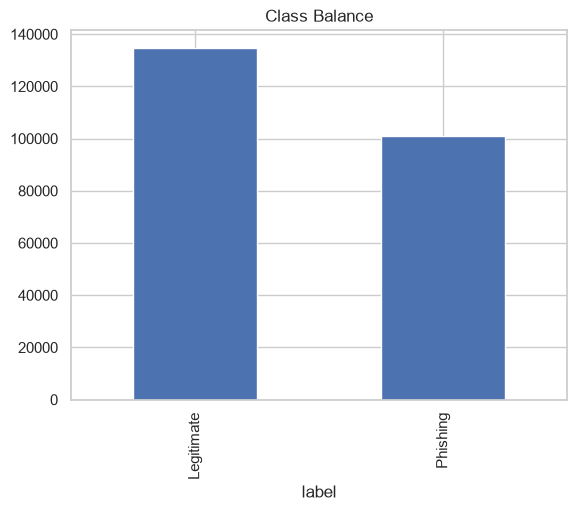

Missing: 0
Duplicates: 0
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL   -0.533537
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
HasTitle                 0.459725
Name: label, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# class balanacing
y.value_counts().rename({1: "Legitimate", 0: "Phishing"}).plot(kind="bar")
plt.title("Class Balance")
plt.show()

print("Missing:", X.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

# top correlated features with label

corr = X.select_dtypes("number").assign(label=y).corr()["label"].drop("label")
top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index).head(15)
print(top_corr)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(188636, 50) (47159, 50)


              precision    recall  f1-score   support

     Phising       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

ROC-AUC: 0.9999999779613244


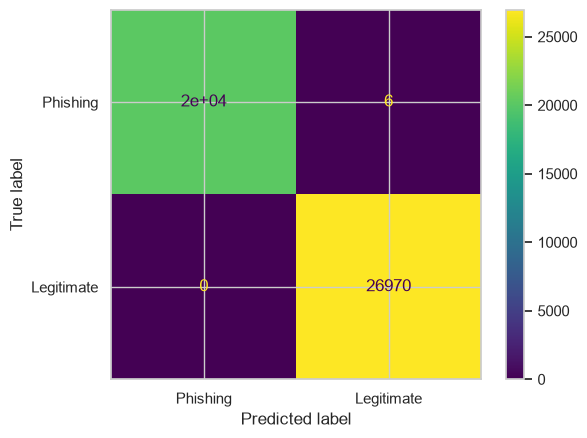

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Phising", "Legitimate"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Phishing", "Legitimate"])
plt.show()

In [8]:
X_train2 = X_train.drop(columns=["URLSimilarityIndex"])
X_test2 = X_test.drop(columns=["URLSimilarityIndex"])

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

logreg2 = LogisticRegression(max_iter=1000, random_state=42)
logreg2.fit(X_train2_scaled, y_train)
print("ROC-AUC without URLSimilarityIndex:", roc_auc_score(y_test, logreg2.predict_proba(X_test2_scaled)[:, 1]))

ROC-AUC without URLSimilarityIndex: 0.9999931569912381


In [9]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), True),
    "Random Forest": (RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42), False),
    "XGBoost": (XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric="logloss", n_jobs=-1, random_state=42), False),
    "LightGBM": (LGBMClassifier(n_estimators=300, n_jobs=-1, random_state=42, verbose=-1), False),
}

In [10]:
from  sklearn.model_selection import StratifiedKFold, cross_validate
scoring = ["accuracy", "f1", "roc_auc", "average_precision"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results={}

for name, (model, use_scaled) in models.items():
    Xc = X_train_scaled if use_scaled else X_train
    res = cross_validate(model, Xc, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: res[f"test_{m}"].mean() for m in scoring}
    print(f"{name} done")

    cv_df = pd.DataFrame(cv_results).T.sort_values("roc_auc", ascending=False)
    cv_df

Logistic Regression done
Random Forest done
XGBoost done
LightGBM done


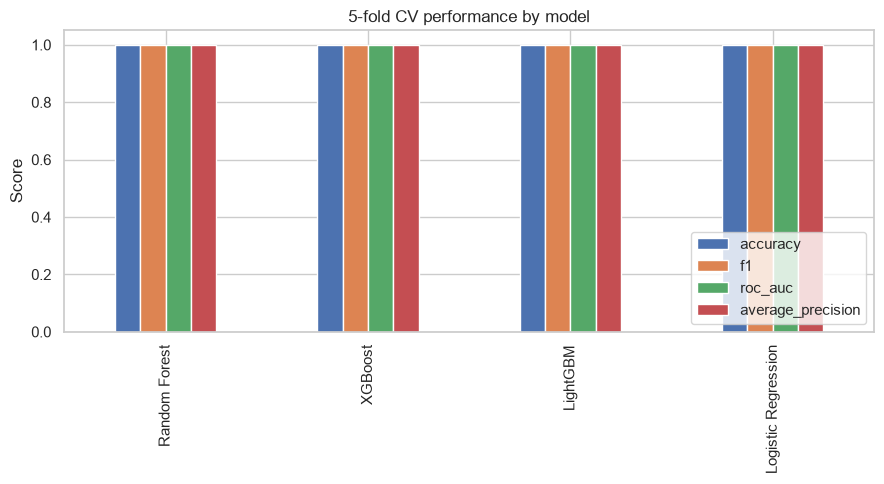

In [11]:
cv_df.plot(kind="bar", figsize=(9,5))
plt.title("5-fold CV performance by model")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
pd.set_option("display.float_format", "{:.6f}".format)
print(cv_df)

                     accuracy       f1  roc_auc  average_precision
Random Forest        1.000000 1.000000 1.000000           1.000000
XGBoost              0.999984 0.999986 1.000000           1.000000
LightGBM             1.000000 1.000000 1.000000           1.000000
Logistic Regression  0.999894 0.999907 0.999997           0.999998


In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_dists = {
    "Random Forest": {
        "n_estimators": [200, 300, 500],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
    },
    "LightGBM": {
        "n_estimators": [200, 300, 500],
        "num_leaves": [31, 63, 127],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
    },
}

top2 = ["Random Forest", "LightGBM"]
tuned_models = {}

for name in top2:
    base_model, use_scaled = models[name]
    Xc = X_train_scaled if use_scaled else X_train
    search = RandomizedSearchCV(
        base_model, param_dists[name], n_iter=20, scoring="roc_auc",
        cv=3, n_jobs=-1, random_state=42, verbose=1,
    )
    search.fit(Xc, y_train)
    print(f"{name}: best ROC-AUC={search.best_score_:.6f}")
    print(f"  best params={search.best_params_}")
    tuned_models[name] = (search.best_estimator_, use_scaled)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Random Forest: best ROC-AUC=1.000000
  best params={'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}
Fitting 3 folds for each of 20 candidates, totalling 60 fits
LightGBM: best ROC-AUC=1.000000
  best params={'subsample': 0.7, 'num_leaves': 127, 'n_estimators': 500, 'learning_rate': 0.01, 'colsample_bytree': 0.85}


=== Random Forest ===
              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

ROC-AUC: 1.0



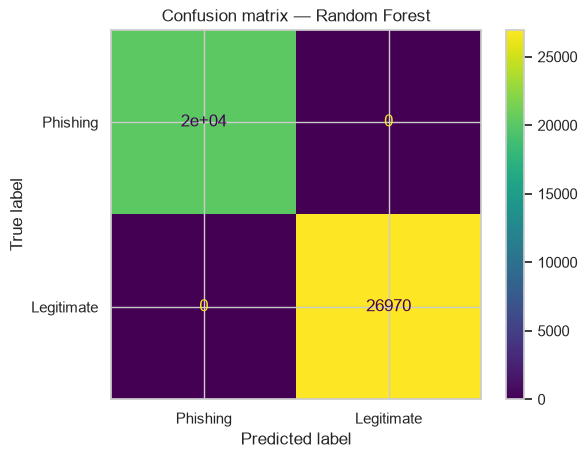

=== LightGBM ===
              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

ROC-AUC: 1.0



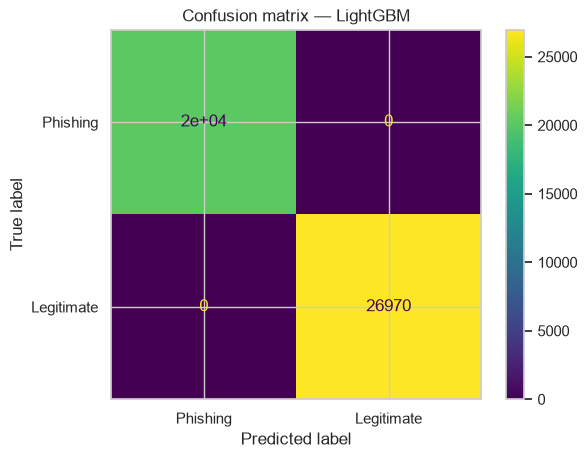

In [14]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
)

fitted = {}
for name, (model, use_scaled) in tuned_models.items():
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test
    model.fit(Xtr, y_train)
    fitted[name] = (model, use_scaled)

    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Phishing", "Legitimate"]))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print()

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Phishing", "Legitimate"])
    plt.title(f"Confusion matrix — {name}")
    plt.show()

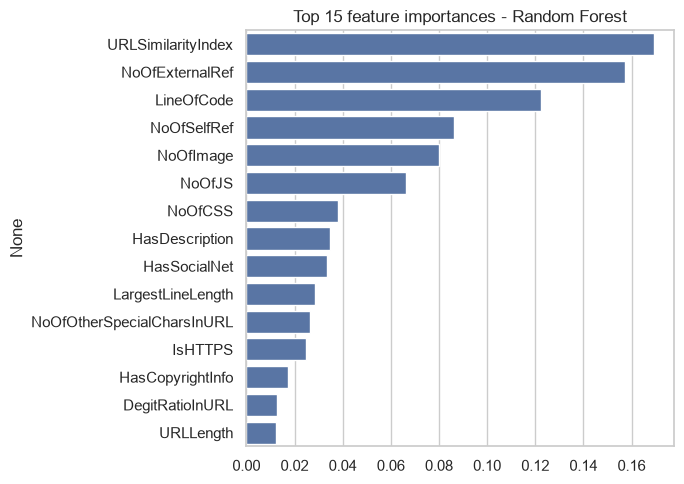

In [21]:
best_model, best_use_scaled = fitted["Random Forest"]

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 feature importances - Random Forest")
plt.tight_layout()
plt.show()

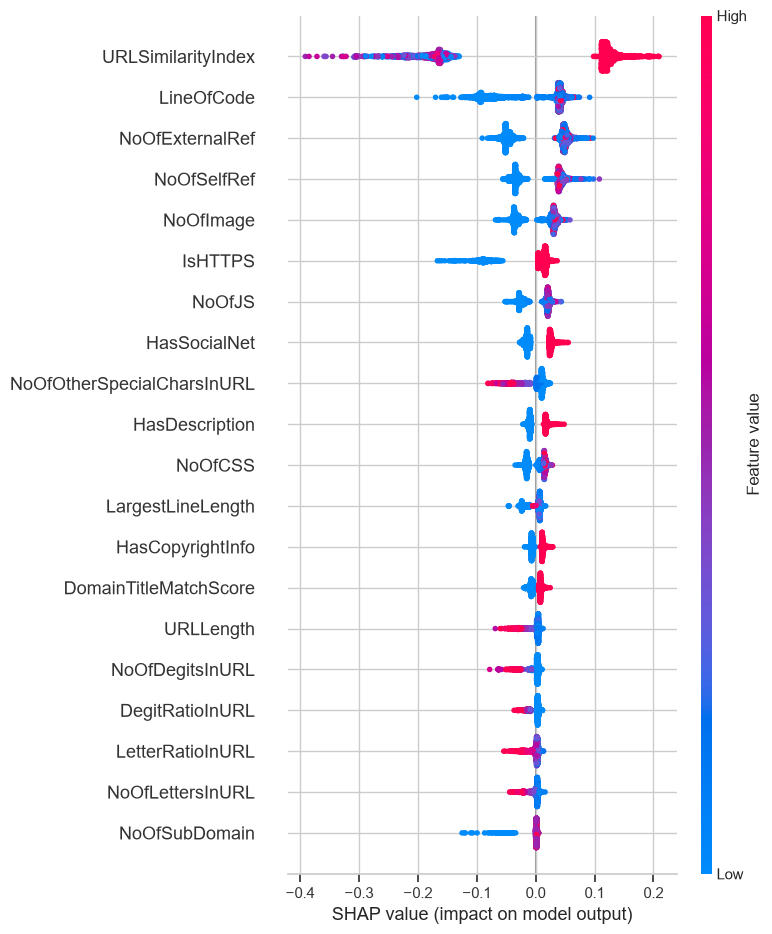

In [22]:
import shap

sample = X_test.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(sample)

sv = shap_values[..., 1] if getattr(shap_values, "ndim", 0) == 3 else (
    shap_values[1] if isinstance(shap_values, list) else shap_values
)
shap.summary_plot(sv, sample, show=True)

In [23]:
URL_ONLY_FEATURES = [
    "URLLength", "DomainLength", "IsDomainIP", "TLDLength", "NoOfSubDomain",
    "HasObfuscation", "NoOfObfuscatedChar", "ObfuscationRatio",
    "NoOfLettersInURL", "LetterRatioInURL", "NoOfDegitsInURL", "DegitRatioInURL",
    "NoOfEqualsInURL", "NoOfQMarkInURL", "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL", "SpacialCharRatioInURL", "IsHTTPS",
]

X_train_urlonly = X_train[URL_ONLY_FEATURES]
X_test_urlonly = X_test[URL_ONLY_FEATURES]

rf_urlonly = RandomForestClassifier(
    n_estimators=200, min_samples_split=5, min_samples_leaf=2,
    max_features="log2", max_depth=30, n_jobs=-1, random_state=42
)
rf_urlonly.fit(X_train_urlonly, y_train)

y_pred_uo = rf_urlonly.predict(X_test_urlonly)
y_proba_uo = rf_urlonly.predict_proba(X_test_urlonly)[:, 1]

print(classification_report(y_test, y_pred_uo, target_names=["Phishing", "Legitimate"]))
print("ROC-AUC (URL-only):", roc_auc_score(y_test, y_proba_uo))

              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

ROC-AUC (URL-only): 0.9985988223303134


In [30]:
import re
import tldextract
from urllib.parse import urlparse

def extract_url_features(url: str) -> dict:
    parsed = urlparse(url if "://" in url else "http://" + url)
    ext = tldextract.extract(url)
    domain = ext.domain + ("." + ext.suffix if ext.suffix else "")
    subdomain = ext.subdomain

    n_letters = sum(c.isalpha() for c in url)
    n_digits = sum(c.isdigit() for c in url)
    n_obfuscated = len(re.findall(r"%[0-9A-Fa-f]{2}", url))
    n_equals, n_qmark, n_amp = url.count("="), url.count("?"), url.count("&")

    # only count genuinely unusual characters — not normal URL syntax (: / . - _)
    STRUCTURAL_CHARS = set(":/.-_")
    n_other_special = sum(
        (not c.isalnum()) and c not in STRUCTURAL_CHARS and c not in "=?&"
        for c in url
    )
    url_len = len(url)

    return {
        "URLLength": url_len,
        "DomainLength": len(domain),
        "IsDomainIP": 1 if re.fullmatch(r"(\d{1,3}\.){3}\d{1,3}", domain) else 0,
        "TLDLength": len(ext.suffix),
        "NoOfSubDomain": len(subdomain.split(".")) if subdomain else 0,
        "HasObfuscation": 1 if n_obfuscated > 0 else 0,
        "NoOfObfuscatedChar": n_obfuscated,
        "ObfuscationRatio": n_obfuscated / url_len if url_len else 0,
        "NoOfLettersInURL": n_letters,
        "LetterRatioInURL": n_letters / url_len if url_len else 0,
        "NoOfDegitsInURL": n_digits,
        "DegitRatioInURL": n_digits / url_len if url_len else 0,
        "NoOfEqualsInURL": n_equals,
        "NoOfQMarkInURL": n_qmark,
        "NoOfAmpersandInURL": n_amp,
        "NoOfOtherSpecialCharsInURL": n_other_special,
        "SpacialCharRatioInURL": (n_equals + n_qmark + n_amp + n_other_special) / url_len if url_len else 0,
        "IsHTTPS": 1 if parsed.scheme == "https" else 0,
    }

In [31]:
import requests

resp = requests.get("https://openphish.com/feed.txt", timeout=15)
phishing_urls = resp.text.strip().split("\n")[:30]   # live feed, no API key needed

legit_urls = [
    "https://www.google.com", "https://www.amazon.co.uk", "https://www.bbc.co.uk",
    "https://github.com", "https://en.wikipedia.org", "https://www.paypal.com",
    "https://www.microsoft.com", "https://www.apple.com", "https://www.gov.uk",
    "https://www.nhs.uk", "https://www.reddit.com", "https://www.linkedin.com",
    "https://www.gmail.com", "https://www.ebay.co.uk", "https://www.netflix.com",
    "https://www.spotify.com", "https://www.uea.ac.uk", "https://www.dropbox.com",
    "https://www.twitch.tv", "https://www.stackoverflow.com", "https://www.cloudflare.com",
    "https://www.nationalgrid.com", "https://www.barclays.co.uk", "https://www.hsbc.co.uk",
    "https://www.tesco.com", "https://www.gov.scot", "https://www.instagram.com",
    "https://www.x.com", "https://www.openai.com", "https://www.wikipedia.org",
]

ood_df = pd.DataFrame([extract_url_features(u) for u in phishing_urls + legit_urls])[URL_ONLY_FEATURES]
ood_labels = [0] * len(phishing_urls) + [1] * len(legit_urls)  # 0=phishing, 1=legit

              precision    recall  f1-score   support

    Phishing       0.50      1.00      0.67        30
  Legitimate       0.00      0.00      0.00        30

    accuracy                           0.50        60
   macro avg       0.25      0.50      0.33        60
weighted avg       0.25      0.50      0.33        60

ROC-AUC (OOD): 0.5977777777777777


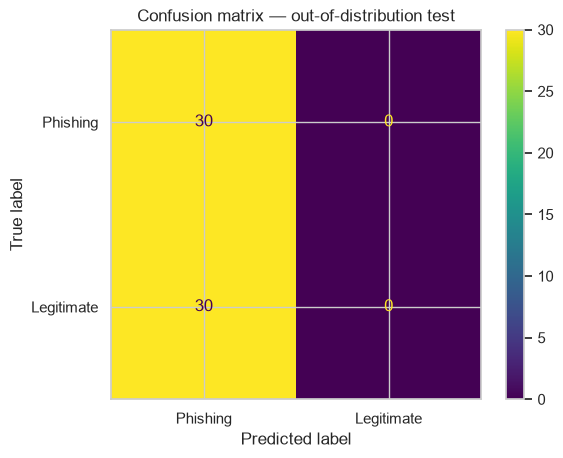

In [35]:
y_pred_ood = rf_urlonly.predict(ood_df)
y_proba_ood = rf_urlonly.predict_proba(ood_df)[:, 1]

print(classification_report(ood_labels, y_pred_ood, target_names=["Phishing", "Legitimate"], zero_division=0))
print("ROC-AUC (OOD):", roc_auc_score(ood_labels, y_proba_ood))

ConfusionMatrixDisplay.from_predictions(ood_labels, y_pred_ood, display_labels=["Phishing", "Legitimate"])
plt.title("Confusion matrix — out-of-distribution test")
plt.show()

In [33]:
print("PhiUSIIL 'legitimate' training URLs — URLLength stats:")
print(X_train.loc[y_train == 1, "URLLength"].describe())

print("\nYour OOD legitimate URLs — URLLength stats:")
print(ood_df.iloc[len(phishing_urls):]["URLLength"].describe())

PhiUSIIL 'legitimate' training URLs — URLLength stats:
count   107880.000000
mean        26.219438
std          4.810552
min         15.000000
25%         23.000000
50%         26.000000
75%         29.000000
max         55.000000
Name: URLLength, dtype: float64

Your OOD legitimate URLs — URLLength stats:
count   30.000000
mean    22.466667
std      2.849481
min     17.000000
25%     21.000000
50%     22.000000
75%     24.000000
max     29.000000
Name: URLLength, dtype: float64


In [34]:
compare = pd.DataFrame({
    "PhiUSIIL_legit_mean": X_train.loc[y_train == 1, URL_ONLY_FEATURES].mean(),
    "OOD_legit_mean": ood_df.iloc[len(phishing_urls):].mean(),
})
compare["diff"] = compare["OOD_legit_mean"] - compare["PhiUSIIL_legit_mean"]
compare.sort_values("diff")

,PhiUSIIL_legit_mean,OOD_legit_mean,diff
DomainLength,19.219438,10.900000,-8.319438
URLLength,26.219438,22.466667,-3.752772
NoOfOtherSpecialCharsInURL,1.245597,0.000000,-1.245597
NoOfSubDomain,1.161930,0.900000,-0.261930
NoOfDegitsInURL,0.051715,0.000000,-0.051715
SpacialCharRatioInURL,0.048399,0.000000,-0.048399
DegitRatioInURL,0.002158,0.000000,-0.002158
NoOfObfuscatedChar,0.000000,0.000000,0.000000
NoOfQMarkInURL,0.000000,0.000000,0.000000
ObfuscationRatio,0.000000,0.000000,0.000000
